# Task 1
Lukas Prader

<Axes: xlabel='day'>

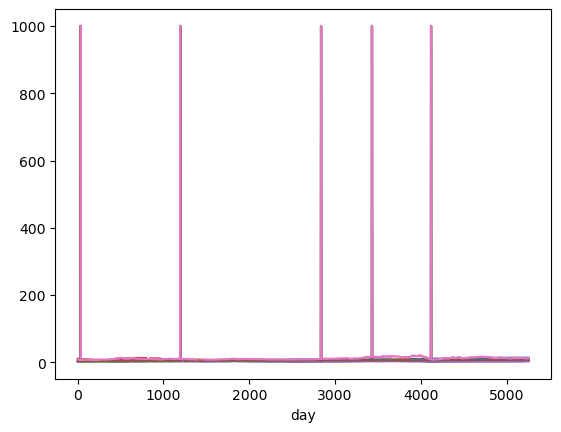

In [6]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data = pd.read_csv("spiff_data-2.csv", index_col=0)
data = data.set_index('day')
data.plot(legend=False)

days with data anomaly


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
1194,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
2836,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
3430,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0
4118,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0,1000.0


new values:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,6.290170,2.842251,2.064018,8.970266,3.606918,3.985158,7.434838
1194,6.838924,5.584437,3.418999,8.763320,3.313187,4.700909,10.321043
2836,9.230156,4.855965,3.850422,6.238832,2.075396,5.889229,10.410045
3430,9.046035,6.818339,4.926725,5.114866,3.304403,6.213680,18.912905
4118,11.417295,4.976386,3.039544,4.585574,1.742467,6.702207,10.047680


variances of the neighboring values:


,gurkor,guitars,slingshots,stocks,sugar,water,tranquillity
day,,,,,,,
36,0.000658,0.000140,0.000038,0.017639,0.001195,0.000122,0.000818
1194,0.000189,0.027081,0.000547,0.005388,0.006674,0.000010,0.000647
2836,0.002367,0.000009,0.001082,0.001152,0.000014,0.000041,0.000010
3430,0.000016,0.000015,0.000002,0.000311,0.000015,0.000035,0.064664
4118,0.002223,0.005589,0.000924,0.002042,0.000341,0.000085,0.024259


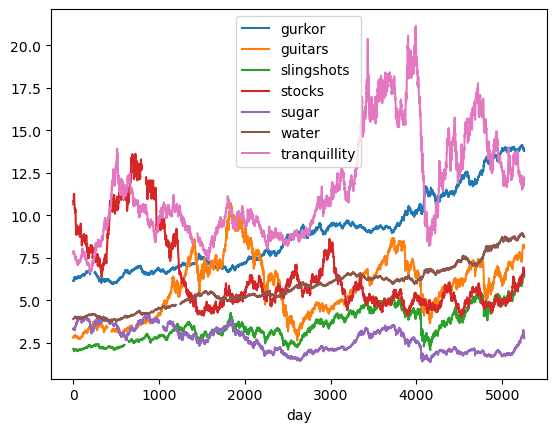

In [7]:
# replace values ==1000 with average of the two neighboring values
indices_1k = data[(data == 1000).any(axis=1)].index

print("days with data anomaly")
display(data.loc[indices_1k])

data.loc[indices_1k] = (
    data.loc[indices_1k + 1].to_numpy() + data.loc[indices_1k - 1].to_numpy()
) / 2

print("new values:")
display(data.loc[indices_1k])

# get variance of the two neighboring values
interp_vars = np.stack(
    [data.loc[indices_1k - 1].to_numpy(), data.loc[indices_1k + 1].to_numpy()], axis=-1
).var(axis=-1)

# variance table with same index/columns format as data.loc[indices_1k]
interp_vars_df = pd.DataFrame(interp_vars, index=indices_1k, columns=data.columns)

print("variances of the neighboring values:")
display(interp_vars_df)

data.plot()

# Save the cleaned data to a new CSV file
os.makedirs("../augmented_data", exist_ok=True)
data.to_csv("../augmented_data/spiff_data_cleaned.csv")

Text(0, 0.5, 'day')

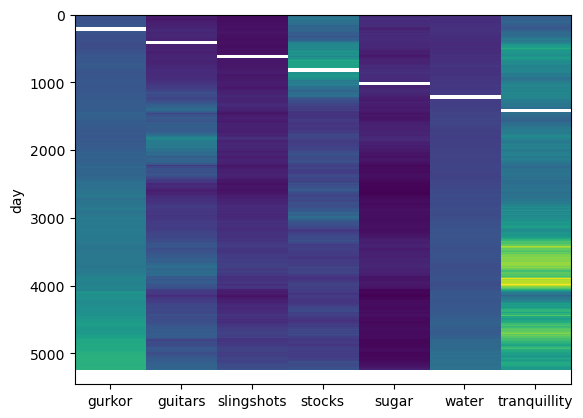

In [8]:
# Visualise the data as a heatmap to show missing value areas
plt.imshow(data, aspect="auto", cmap="viridis", interpolation="none")
plt.xticks(ticks=np.arange(data.shape[1]), labels=data.columns)
plt.ylabel("day")

## What patterns exist within the individual series?

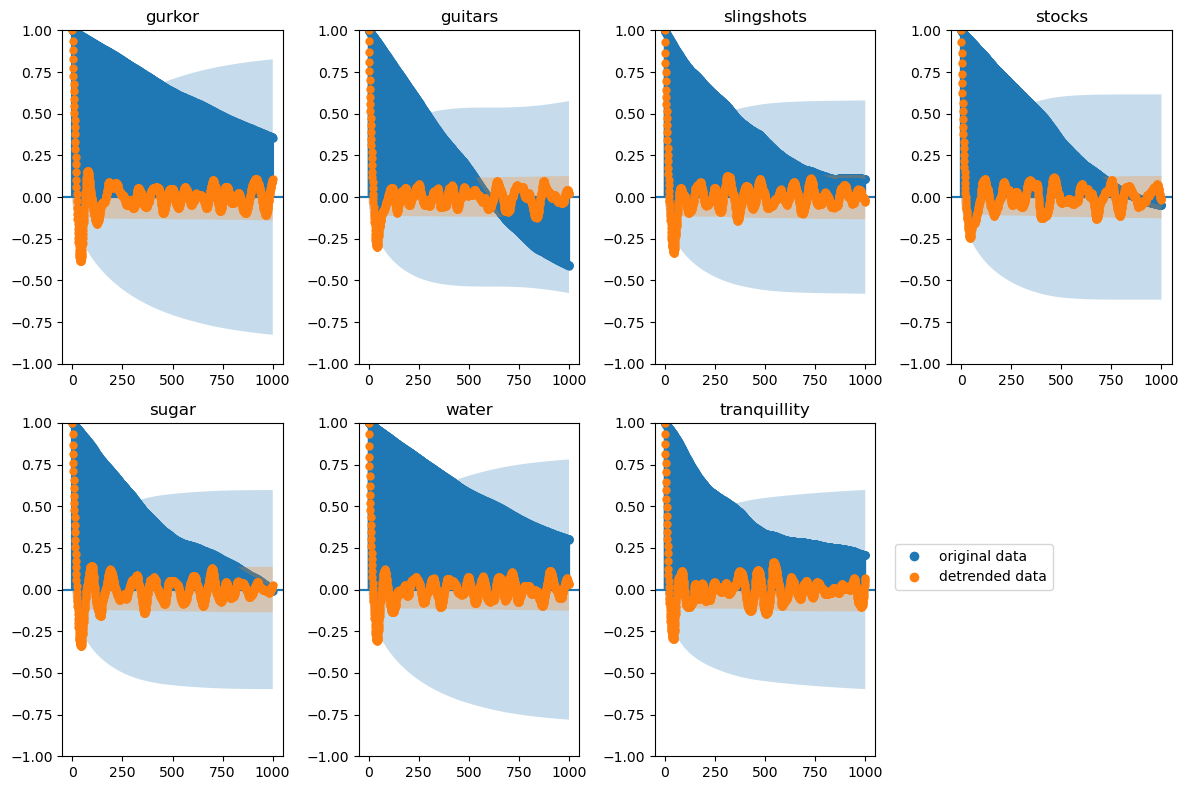

In [9]:
# Visualise effect of trend and seasonality on ACF
import statsmodels.api as sm
from matplotlib.lines import Line2D

data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

fig, axes = plt.subplots(2, 4, figsize=(4 * 3, 4 * 2))
axes = axes.flatten()

for i, col_name in enumerate(data_clean.columns):
    data_usable = data_clean[col_name].dropna()

    sm.graphics.tsa.plot_acf(
        data_usable,
        lags=1000,
        ax=axes[i],
        title=col_name,
        zorder = 1,
        label="original data"
    )

    window_size = 100
    ts_ma = data_clean[col_name].rolling(window=window_size, center=True).mean()
    ts_detrended = (data_clean[col_name] - ts_ma).dropna().to_numpy()

    sm.graphics.tsa.plot_acf(
        ts_detrended,
        lags=1000,
        ax=axes[i],
        title=col_name,
        zorder = 2,
        label="detrended data"
    )

# Create legend in bottom right subplot
axes[7].set_visible(False)
bbox = axes[7].get_position()

handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', markersize=8)
]
fig.legend(handles, ['original data', 'detrended data'], bbox_to_anchor=bbox, loc='center', frameon=True)
plt.tight_layout()
plt.show()


{'gurkor': array([ 83, 250,  36]), 'guitars': array([100,  62,  31]), 'slingshots': array([ 83, 167,  36]), 'stocks': array([125,  62,  36]), 'sugar': array([100, 167,  31,  36]), 'water': array([ 83, 250,  45,  36]), 'tranquillity': array([83, 31, 38])}


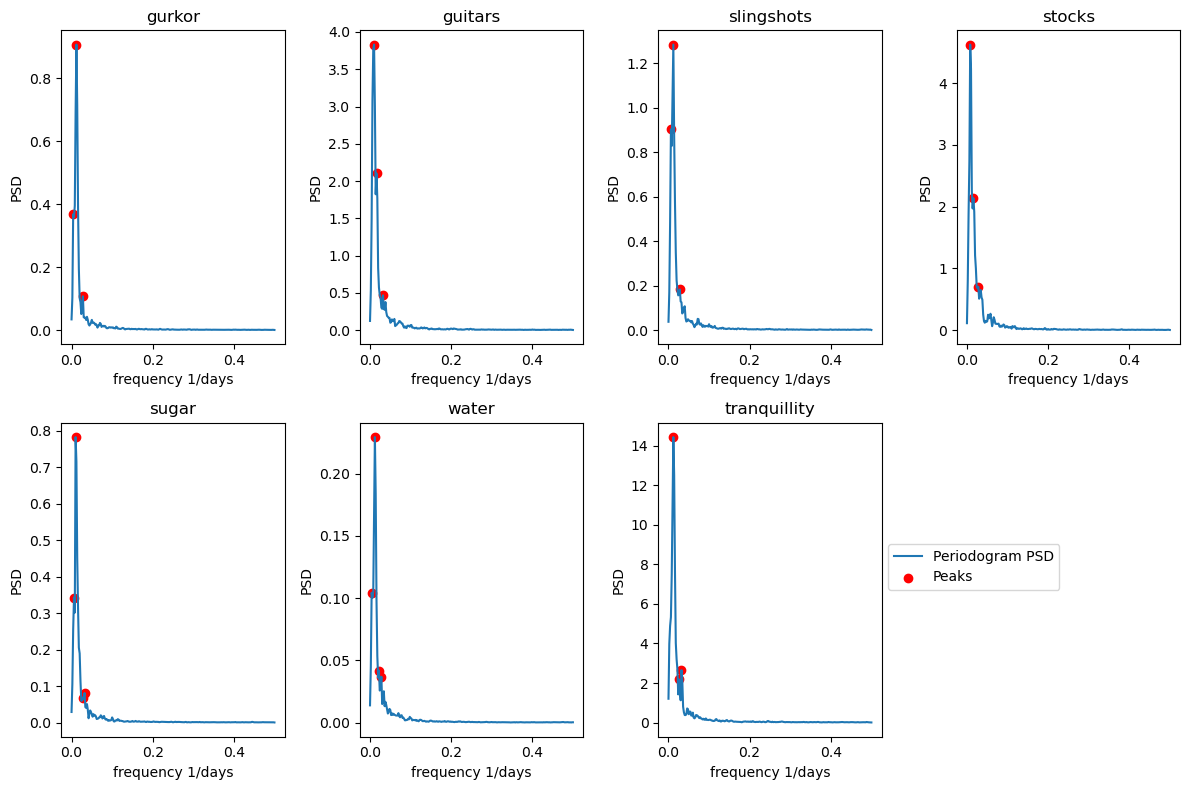

In [10]:
import scipy as sp

data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

fig, axes = plt.subplots(2, 4, figsize=(4 * 3, 4 * 2))
axes = axes.flatten()

found_periods = {}
for i, col_name in enumerate(data_clean.columns):

    # detrend using moving average
    ts_ma = data_clean[col_name].rolling(window=100, center=True).mean()
    ts_detrended = (data_clean[col_name] - ts_ma).dropna().to_numpy()

    # periodogram using welch to determine
    f, Pxx_den = sp.signal.welch(ts_detrended, fs=1, nperseg=500)
    axes[i].plot(f, Pxx_den, label = "Periodogram PSD")
    axes[i].set_xlabel('frequency 1/days')
    axes[i].set_ylabel('PSD')
    axes[i].set_title(col_name)

    # find peaks
    peaks, properties = sp.signal.find_peaks(Pxx_den, height=np.percentile(Pxx_den, 95))
    axes[i].scatter(f[peaks], Pxx_den[peaks], color="red", label = "Peaks")

    # peaks sorted by height
    found_periods[col_name] = np.rint(1/f[peaks[np.argsort(properties["peak_heights"])[::-1]]]).astype(int)

# hide any unused panels
axes[7].set_visible(False)
bbox = axes[7].get_position()

# Single legend in the 8th subplot area
fig.legend(['Periodogram PSD', 'Peaks'], bbox_to_anchor=bbox, loc='center', frameon=True)

print(found_periods)

plt.tight_layout()
plt.show()

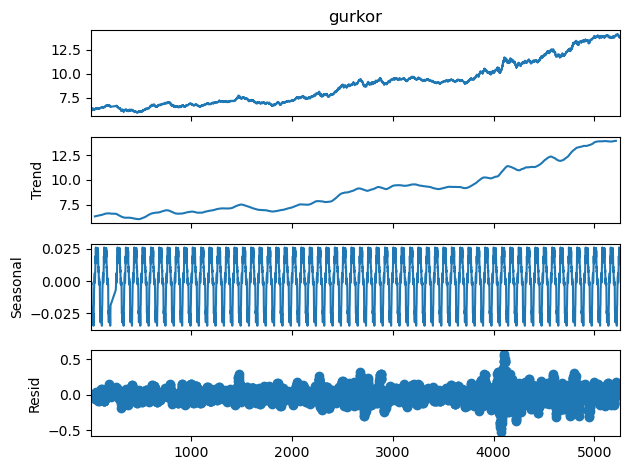

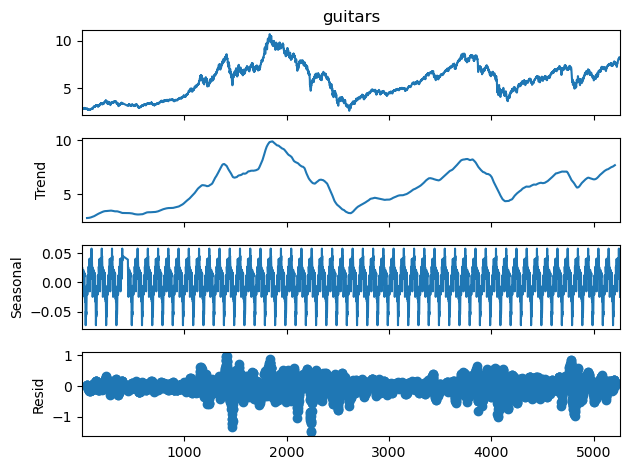

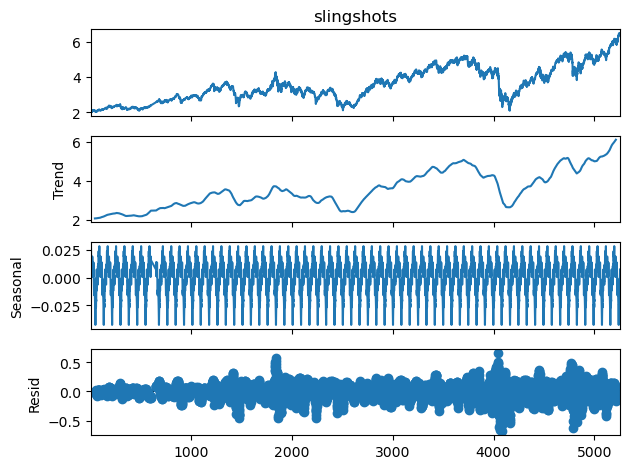

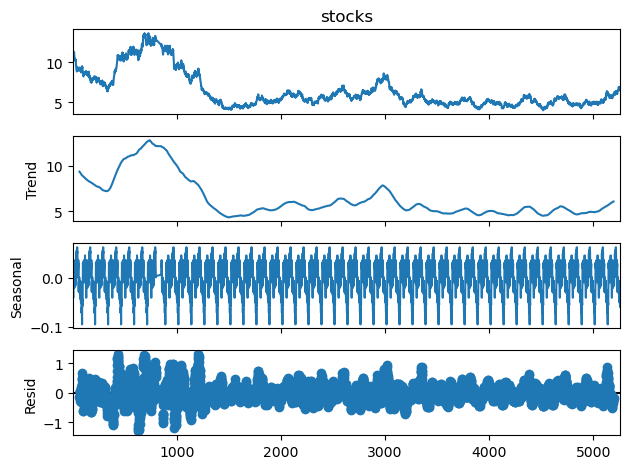

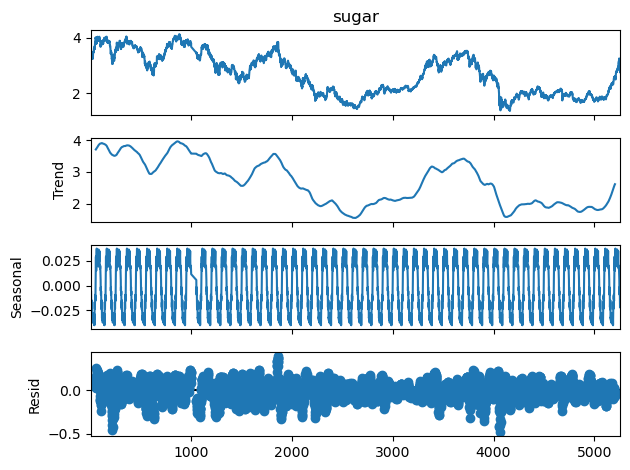

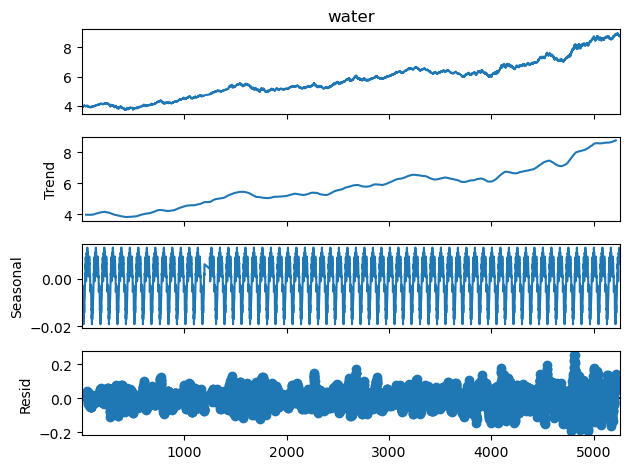

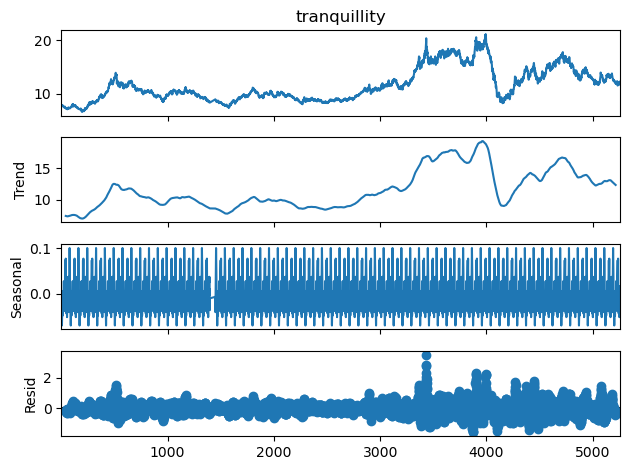

In [11]:
# Seasonal decomposition using the strongest found period for each time series

from statsmodels.tsa.seasonal import seasonal_decompose

plots = []
for i, col_name in enumerate(data_clean.columns):

    ts = data_clean[col_name].dropna()
    ts.reindex(range(len(ts)))

    decomposition = seasonal_decompose(ts, model='additive', period=found_periods[col_name][0])
    
    plots.append(decomposition.plot())

In [12]:
# convert ts to returns 
data_clean = pd.read_csv("../augmented_data/spiff_data_cleaned.csv", index_col="day")

returns_data = data_clean.pct_change().dropna()

from statsmodels.tsa.stattools import adfuller, kpss

# store results in dataframe
results_df = pd.DataFrame(columns=["ADF p-value", "KPSS p-value"], index=returns_data.columns)
for col_name in returns_data.columns:

    result_adf = adfuller(returns_data[col_name].dropna())
    result_kpss = kpss(returns_data[col_name].dropna(), regression='c')

    results_df.loc[col_name] = [result_adf[1], result_kpss[1]]

results_df

C:\Users\tommi\AppData\Local\Temp\ipykernel_13628\2067633894.py:4: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns_data = data_clean.pct_change().dropna()
C:\Users\tommi\AppData\Local\Temp\ipykernel_13628\2067633894.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(returns_data[col_name].dropna(), regression='c')
C:\Users\tommi\AppData\Local\Temp\ipykernel_13628\2067633894.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  result_kpss = kpss(returns_data[col_name].dropna(), regression='c')
C:\Users\tommi\AppData\Loca

,ADF p-value,KPSS p-value
gurkor,0.0,0.1
guitars,0.0,0.1
slingshots,0.0,0.1
stocks,0.0,0.1
sugar,0.0,0.1
water,0.0,0.1
tranquillity,0.0,0.1


In [18]:
# get average daily and 100 day cumulativereturns and variances per time series
summary_df = pd.DataFrame(columns=["mean return", "return variance", "100 day mean cumulative return", "100 day return variance"], index=returns_data.columns)
for col_name in returns_data.columns:

    cumulative_100 = returns_data[col_name].rolling(window=100).sum()

    summary_df.loc[col_name, "mean return"] = returns_data[col_name].mean()
    summary_df.loc[col_name, "100 day mean cumulative return"] = cumulative_100.mean()
    summary_df.loc[col_name, "return variance"] = returns_data[col_name].var()
    summary_df.loc[col_name, "100 day return variance"] = cumulative_100.var()

summary_df

,mean return,return variance,100 day mean cumulative return,100 day return variance
gurkor,0.000155,0.000015,0.015307,0.001418
guitars,0.000301,0.000213,0.030427,0.019822
slingshots,0.000306,0.000207,0.031636,0.014532
stocks,0.000016,0.000213,0.003712,0.020528
sugar,0.000076,0.000221,0.00574,0.018693
water,0.000154,0.000012,0.015367,0.001181
tranquillity,0.000159,0.000152,0.017035,0.019179


## What relationships exist between the different series?

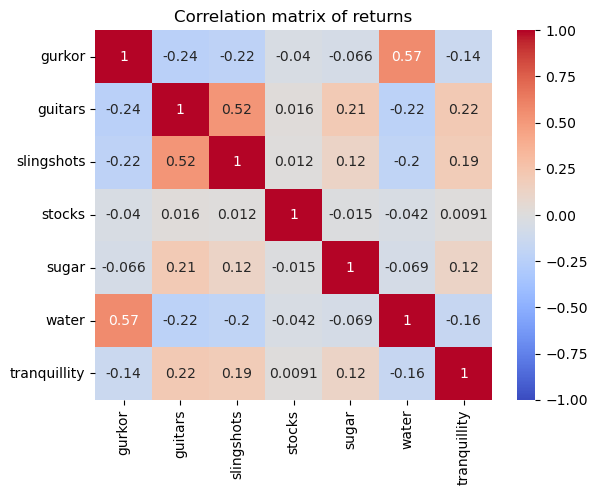

In [19]:
# Correlation matrix of the time series
import seaborn as sns
corrmat = returns_data.corr()

sns.heatmap(corrmat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of returns")
plt.show()

In [29]:
granger_results = pd.DataFrame(columns=["significant lags", "p-values"])
granger_results

,significant lags,p-values


In [78]:
# Compute granger causality tests for all pairs of time series
from statsmodels.tsa.stattools import grangercausalitytests

max_lag = 10


granger_results = pd.DataFrame(columns=["tested", "caused by", "significant lags", "p-values"])
for col1 in returns_data.columns:
    for col2 in returns_data.columns:
        if col1 != col2:
            test_result = grangercausalitytests(returns_data[[col1, col2]].dropna(), maxlag=max_lag, verbose=False)
            p_values = [np.round(test_result[lag][0]['ssr_chi2test'][1], 3) for lag in range(1, max_lag+1)]

            significant_p_values = [p for p in p_values if p < 0.05]

            if len(significant_p_values) > 0:

                significant_lags = [lag for lag in range(1, max_lag+1) if p_values[lag-1] < 0.05]

                granger_results.loc[len(granger_results)] = [col1, col2, significant_lags, significant_p_values]

display(granger_results)

/home/luprader/Desktop/chalmers/semester_2/financial_timeseries/project_FTS/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/luprader/Desktop/chalmers/semester_2/financial_timeseries/project_FTS/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/luprader/Desktop/chalmers/semester_2/financial_timeseries/project_FTS/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/luprader/Desktop/chalmers/semester_2/financial_timeseries/project_FTS/.venv/lib/python3.13/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/home/luprader/Desktop/chalmers/seme

,tested,caused by,significant lags,p-values
0,gurkor,sugar,"[5, 6, 7, 8, 9, 10]","[0.009, 0.024, 0.014, 0.025, 0.008, 0.015]"
1,gurkor,water,"[4, 5, 6, 7, 8]","[0.015, 0.007, 0.018, 0.028, 0.043]"
2,guitars,gurkor,"[1, 3]","[0.044, 0.034]"
3,guitars,slingshots,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,guitars,sugar,"[1, 2, 3, 4]","[0.012, 0.021, 0.017, 0.037]"
5,guitars,tranquillity,[1],[0.014]
6,slingshots,guitars,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.001, 0.003, 0.003, 0.004, 0.004, 0.006, 0.0..."
7,slingshots,sugar,"[4, 7, 8, 9, 10]","[0.002, 0.035, 0.002, 0.014, 0.002]"
8,sugar,gurkor,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
9,sugar,guitars,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


## Additional analyses

Task 4) Johansen Test for mean reversion

In [99]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

res = coint_johansen(data_clean.dropna(), det_order=0, k_ar_diff=1)

print("trace statistic:", res.trace_stat)
print("trace critical values:", res.trace_stat_crit_vals)
print("maximum eigenvalue statistic:", res.max_eig_stat)
print("maximum eigenvalue critical values:", res.max_eig_stat_crit_vals)

trace statistic: [1.17655905e+02 7.11727869e+01 4.34174429e+01 2.20113137e+01
 1.16890776e+01 3.41027713e+00 5.94361406e-03]
trace critical values: [[120.3673 125.6185 135.9825]
 [ 91.109   95.7542 104.9637]
 [ 65.8202  69.8189  77.8202]
 [ 44.4929  47.8545  54.6815]
 [ 27.0669  29.7961  35.4628]
 [ 13.4294  15.4943  19.9349]
 [  2.7055   3.8415   6.6349]]
maximum eigenvalue statistic: [4.64831180e+01 2.77553440e+01 2.14061292e+01 1.03222361e+01
 8.27880044e+00 3.40433352e+00 5.94361406e-03]
maximum eigenvalue critical values: [[43.2947 46.2299 52.3069]
 [37.2786 40.0763 45.8662]
 [31.2379 33.8777 39.3693]
 [25.1236 27.5858 32.7172]
 [18.8928 21.1314 25.865 ]
 [12.2971 14.2639 18.52  ]
 [ 2.7055  3.8415  6.6349]]


## Can the series be grouped?

To answer this we look at the **returns** (since price levels are non-stationary and on different scales) from three angles:

1. The return correlation matrix — which series move together?
2. Return volatility — how big are the daily moves for each series?
3. A simple visual check on the correlation matrix to confirm the groups.

In [24]:
# Load data and clean the 1000-anomaly the same way as in cell 1 and cell 2 above
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv("spiff_data-2.csv", index_col=0)
data = data.set_index('day')

# replace 1000-anomalies with average of neighbours (same logic as cell 2)
indices_1k = data[(data == 1000).any(axis=1)].index
data.loc[indices_1k] = (
    data.loc[indices_1k + 1].to_numpy() + data.loc[indices_1k - 1].to_numpy()
) / 2

# work with returns
returns = data.pct_change().dropna()
print("Number of return observations:", len(returns))

Number of return observations: 5455


C:\Users\tommi\AppData\Local\Temp\ipykernel_13628\763056085.py:16: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = data.pct_change().dropna()


### Correlation matrix of returns

We already saw the correlation matrix in the section above. Let's reprint it here so we can read off the grouping directly.

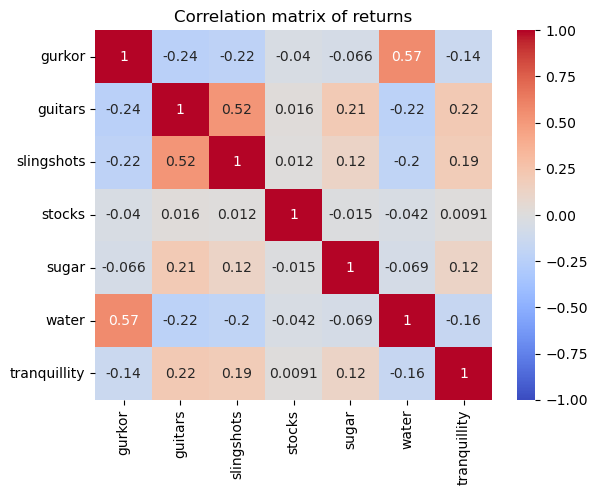

              gurkor  guitars  slingshots  stocks  sugar  water  tranquillity
gurkor          1.00    -0.24       -0.22   -0.04  -0.07   0.57         -0.14
guitars        -0.24     1.00        0.52    0.02   0.21  -0.22          0.22
slingshots     -0.22     0.52        1.00    0.01   0.12  -0.20          0.19
stocks         -0.04     0.02        0.01    1.00  -0.01  -0.04          0.01
sugar          -0.07     0.21        0.12   -0.01   1.00  -0.07          0.12
water           0.57    -0.22       -0.20   -0.04  -0.07   1.00         -0.16
tranquillity   -0.14     0.22        0.19    0.01   0.12  -0.16          1.00


In [25]:
import seaborn as sns

corrmat = returns.corr()
sns.heatmap(corrmat, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix of returns")
plt.show()

print(corrmat.round(2))

Reading the matrix:

* `gurkor` and `water` are positively correlated (~+0.57) and negatively correlated with most of the others.
* `guitars`, `slingshots`, `sugar`, `tranquillity` are positively correlated with each other.
* `stocks` has near-zero correlation with everything (all values within ±0.05).

### Return volatility

Looking at the size of daily moves should also tell us something — series in the same group tend to have similar volatility.

Daily return std:
water           0.00343
gurkor          0.00385
tranquillity    0.01231
slingshots      0.01439
guitars         0.01458
stocks          0.01459
sugar           0.01486
dtype: float64


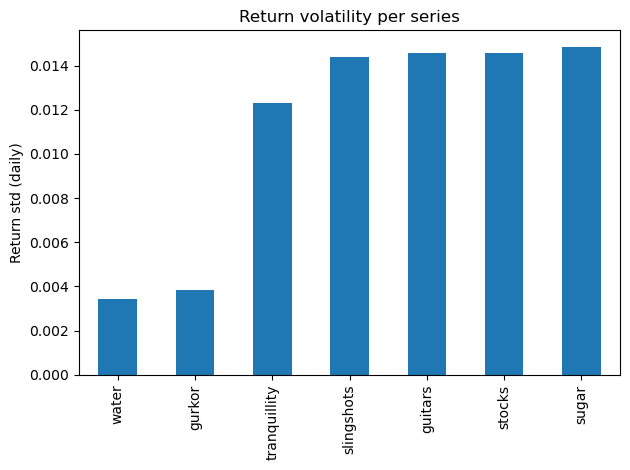

In [26]:
# daily return std for each series, sorted
vol = returns.std().sort_values()
print("Daily return std:")
print(vol.round(5))

vol.plot(kind='bar')
plt.ylabel("Return std (daily)")
plt.title("Return volatility per series")
plt.tight_layout()
plt.show()

### Conclusion: three groups

Both the correlation matrix and the volatility plot point to the same grouping:

| Group | Members | Daily return std | Defining feature |
|---|---|---|---|
| **A — low-volatility pair** | `gurkor`, `water` | ~0.4% | Strongly positively correlated with each other (+0.57), negatively correlated with Group B |
| **B — high-volatility cluster** | `guitars`, `slingshots`, `sugar`, `tranquillity` | ~1.2–1.5% | Mutually positively correlated, especially guitars/slingshots (+0.53) |
| **C — independent** | `stocks` | ~1.5% | Correlations with everything else are essentially zero |

This is useful for the next tasks:

* **Task 2 (interpolation):** when filling a gap in `gurkor`, `water` is a strong covariate. For Group B series, the other three help. For `stocks`, no other series helps — it has to be done from its own history.
* **Task 3 (extrapolation):** same idea applies. `stocks` looks like a univariate-model case.
* **Task 4 (portfolio):** the negative correlation between Groups A and B is real diversification, and `stocks` adds a third near-independent return stream.

## Additional question: are the groups stable over time?

The grouping above is computed on the full sample. But that average can hide a market that switches between regimes. If the correlation between Group A and Group B sometimes flips sign, a strategy that bets on the average correlation will sometimes lose its diversification benefit.

So: do the relationships stay the same over time, or do they change? We check this with a rolling 252-day (~one Spiff year) correlation.

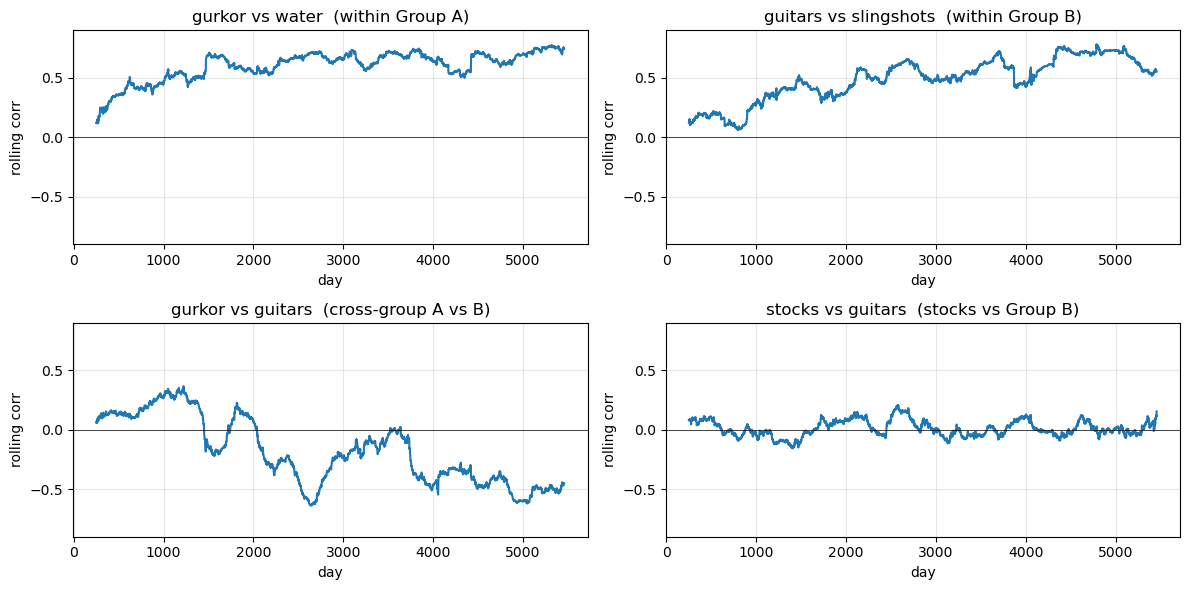

In [27]:
# Pairs that represent each "situation": within-group, cross-group, stocks-vs-rest
window = 252

pairs_to_check = [
    ('gurkor', 'water',       'within Group A'),
    ('guitars', 'slingshots', 'within Group B'),
    ('gurkor', 'guitars',     'cross-group A vs B'),
    ('stocks', 'guitars',     'stocks vs Group B'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 6))
axes = axes.flatten()

for ax, (a, b, label) in zip(axes, pairs_to_check):
    rolling_corr = returns[a].rolling(window).corr(returns[b])
    ax.plot(rolling_corr.index, rolling_corr.values)
    ax.axhline(0, color='black', linewidth=0.5)
    ax.set_ylim(-0.9, 0.9)
    ax.set_title(f"{a} vs {b}  ({label})")
    ax.set_xlabel("day")
    ax.set_ylabel("rolling corr")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [28]:
# Numerical summary of how stable each correlation is
summary = pd.DataFrame(columns=["mean", "std", "min", "max"])
for a, b, label in pairs_to_check:
    rc = returns[a].rolling(window).corr(returns[b]).dropna()
    summary.loc[f"{a} vs {b}"] = [rc.mean(), rc.std(), rc.min(), rc.max()]

print(summary.round(3))

                        mean    std    min    max
gurkor vs water        0.601  0.121  0.118  0.776
guitars vs slingshots  0.489  0.179  0.059  0.783
gurkor vs guitars     -0.184  0.277 -0.637  0.367
stocks vs guitars      0.011  0.067 -0.156  0.207


### What the rolling correlations show

* **Within Group A** (`gurkor` vs `water`): correlation stays positive across the whole sample (never drops below ~0.35). The group is stable.
* **Within Group B** (`guitars` vs `slingshots`): also stays positive, but the magnitude varies more (between ~0.10 and ~0.78).
* **Cross-group A vs B** (`gurkor` vs `guitars`): this is the **unstable** one. It swings between roughly -0.64 and +0.28 and crosses zero. The full-sample number (-0.24) hides a relationship that flips sign at times.
* **Stocks vs Group B** (`stocks` vs `guitars`): stays close to zero throughout (within ±0.21), confirming `stocks` is consistently independent.

**Takeaway for tasks 3 and 4:** the groups themselves are real and stable, but the *negative* correlation between Group A and Group B is not always there. Any strategy or model that depends on the sign of the A–B relationship needs to either use a time-varying correlation estimate (e.g. rolling window or DCC-GARCH) or be hedged against the periods when that correlation goes positive.